### Display MTEB results
MTEB results are saved in .json files, one for each task. 
This notebook aggregates the results for multiple tasks and multiple models.

In [1]:
import mteb
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import regex as re
import math
import os

In [2]:
# get task type 
mteb.get_task("ArguAna").metadata.type

'Retrieval'

In [3]:
mteb.get_task("ArguAna").metadata.name

'ArguAna'

#### Analyze MTEB results of different TF-IDF configurations

In [4]:
data = {}
main_dir = "../MTEB/sparse_results/Tfidf"

# Traverse folders and subfolders
for (root, dirs, files) in os.walk(main_dir):
    # Identify model version from the folder structure
    model_version = os.path.basename(root)
    print(model_version)
        
    for file in files:
        # Skip unwanted files
        if file in {"model_meta.json"} or not file.endswith('.json'):
            continue
            
        file_path = os.path.join(root, file)
        try:
            # Read JSON and extract necessary fields
            with open(file_path, 'r') as f:
                json_data = json.load(f)
                task_name = json_data.get("task_name")
                main_score = json_data.get("scores", {}).get("test", {})[0]["main_score"]
                main_score = round(main_score*100, 2)
                    
                if task_name and main_score is not None:
                    if task_name not in data:
                        data[task_name] = {}
                    data[task_name][model_version] = main_score
        except (json.JSONDecodeError, KeyError):
            print(f"Error parsing file: {file_path}")


Tfidf
tfidf_log
svd300_log
svd50_log
svd_log_piecewise
svd_log_novocab
1.0
svd500_log
svd200_log
svd_log_old
rnd768_log
svd
svd768_log
svd_log
rnd100_log
rnd500_log


In [5]:
df = pd.DataFrame.from_dict(data, orient='index')
df.index.name = "task_name"
df["task_types"] = [mteb.get_task(task).metadata.type for task in df.index]

In [6]:
task_selection = ["ArguAna", "ArxivClusteringP2P", "BiorxivClusteringP2P", "MedrxivClusteringP2P", "MindSmallReranking",
                 "RedditClusteringP2P", "SCIDOCS", "SciDocsRR", "StackExchangeClusteringP2P", "STS15", "STS16",
                 "STSBenchmark"]

df = df.loc[task_selection].sort_values("task_types")
df

,tfidf_log,svd300_log,svd50_log,svd_log_piecewise,svd_log_novocab,1.0,svd500_log,svd200_log,svd_log_old,rnd768_log,svd,svd768_log,svd_log,rnd100_log,rnd500_log,task_types
task_name,,,,,,,,,,,,,,,,
ArxivClusteringP2P,35.28,40.71,39.77,39.97,41.73,26.72,41.15,40.59,41.73,28.91,36.95,41.18,40.34,9.02,24.31,Clustering
BiorxivClusteringP2P,26.44,33.87,33.53,34.02,33.80,20.56,33.40,33.63,33.80,18.80,28.47,33.04,33.93,4.01,15.66,Clustering
MedrxivClusteringP2P,20.82,29.53,29.64,29.87,30.00,19.30,29.12,29.68,30.00,18.66,28.62,28.53,29.81,10.96,15.02,Clustering
RedditClusteringP2P,40.32,38.37,34.26,33.99,45.96,31.55,40.64,36.67,45.96,32.07,39.83,43.62,34.53,11.42,29.43,Clustering
StackExchangeClusteringP2P,16.94,31.68,35.97,34.07,34.00,18.72,29.87,32.83,34.03,15.83,32.71,27.90,34.18,17.33,16.80,Clustering
MindSmallReranking,NaN,27.37,25.87,NaN,NaN,NaN,NaN,27.08,NaN,26.96,23.44,NaN,26.64,24.85,26.92,Reranking
SciDocsRR,62.34,58.63,48.30,NaN,NaN,62.30,60.47,56.47,NaN,61.64,28.35,61.95,52.69,52.38,60.94,Reranking
ArguAna,52.54,51.04,33.31,NaN,NaN,42.48,53.94,48.15,NaN,41.78,0.04,55.56,41.56,11.14,38.04,Retrieval
SCIDOCS,14.69,7.73,4.09,NaN,NaN,13.31,9.58,6.73,NaN,12.85,0.04,10.76,5.31,3.73,11.76,Retrieval


#### Figure 1 / Table 1: compare MTEB performance of different TF-IDF versions 
excluded models: 
- svd_log_piecewise
- svd_log_novocab
- svd_log_old
- svd

These are excluded bc either svd or svd and vocab are computed for the batch, not for the entire data in clustering tasks. This differentiation doesn't make sense for the other tasks, so it is disregarded

In [7]:
df_mteb = df.drop(["svd_log_piecewise", "svd_log_novocab", "svd_log_old", "svd"], axis=1)

model_order = ["1.0", "tfidf_log", "svd50_log", "svd_log", "svd200_log", "svd300_log", "svd500_log", "svd768_log", "rnd100_log", "rnd500_log", "rnd768_log", "task_types"]
df_mteb = df_mteb.reindex(columns=model_order).rename(columns={"1.0": "full tfidf (no log)", "tfidf_log": "full tfidf"})
df_mteb

,full tfidf (no log),full tfidf,svd50_log,svd_log,svd200_log,svd300_log,svd500_log,svd768_log,rnd100_log,rnd500_log,rnd768_log,task_types
task_name,,,,,,,,,,,,
ArxivClusteringP2P,26.72,35.28,39.77,40.34,40.59,40.71,41.15,41.18,9.02,24.31,28.91,Clustering
BiorxivClusteringP2P,20.56,26.44,33.53,33.93,33.63,33.87,33.40,33.04,4.01,15.66,18.80,Clustering
MedrxivClusteringP2P,19.30,20.82,29.64,29.81,29.68,29.53,29.12,28.53,10.96,15.02,18.66,Clustering
RedditClusteringP2P,31.55,40.32,34.26,34.53,36.67,38.37,40.64,43.62,11.42,29.43,32.07,Clustering
StackExchangeClusteringP2P,18.72,16.94,35.97,34.18,32.83,31.68,29.87,27.90,17.33,16.80,15.83,Clustering
MindSmallReranking,NaN,NaN,25.87,26.64,27.08,27.37,NaN,NaN,24.85,26.92,26.96,Reranking
SciDocsRR,62.30,62.34,48.30,52.69,56.47,58.63,60.47,61.95,52.38,60.94,61.64,Reranking
ArguAna,42.48,52.54,33.31,41.56,48.15,51.04,53.94,55.56,11.14,38.04,41.78,Retrieval
SCIDOCS,13.31,14.69,4.09,5.31,6.73,7.73,9.58,10.76,3.73,11.76,12.85,Retrieval


In [8]:
df_mteb.to_latex(na_rep="-", float_format="%.2f")

'\\begin{tabular}{lrrrrrrrrrrrl}\n\\toprule\n & full tfidf (no log) & full tfidf & svd50_log & svd_log & svd200_log & svd300_log & svd500_log & svd768_log & rnd100_log & rnd500_log & rnd768_log & task_types \\\\\ntask_name &  &  &  &  &  &  &  &  &  &  &  &  \\\\\n\\midrule\nArxivClusteringP2P & 26.72 & 35.28 & 39.77 & 40.34 & 40.59 & 40.71 & 41.15 & 41.18 & 9.02 & 24.31 & 28.91 & Clustering \\\\\nBiorxivClusteringP2P & 20.56 & 26.44 & 33.53 & 33.93 & 33.63 & 33.87 & 33.40 & 33.04 & 4.01 & 15.66 & 18.80 & Clustering \\\\\nMedrxivClusteringP2P & 19.30 & 20.82 & 29.64 & 29.81 & 29.68 & 29.53 & 29.12 & 28.53 & 10.96 & 15.02 & 18.66 & Clustering \\\\\nRedditClusteringP2P & 31.55 & 40.32 & 34.26 & 34.53 & 36.67 & 38.37 & 40.64 & 43.62 & 11.42 & 29.43 & 32.07 & Clustering \\\\\nStackExchangeClusteringP2P & 18.72 & 16.94 & 35.97 & 34.18 & 32.83 & 31.68 & 29.87 & 27.90 & 17.33 & 16.80 & 15.83 & Clustering \\\\\nMindSmallReranking & - & - & 25.87 & 26.64 & 27.08 & 27.37 & - & - & 24.85 & 26.92 

In [9]:
# melt into long format
df_melted = df_mteb.reset_index().melt(id_vars=["task_name", "task_types"], var_name="version", value_name="score")
df_melted

,task_name,task_types,version,score
0,ArxivClusteringP2P,Clustering,full tfidf (no log),26.72
1,BiorxivClusteringP2P,Clustering,full tfidf (no log),20.56
2,MedrxivClusteringP2P,Clustering,full tfidf (no log),19.30
3,RedditClusteringP2P,Clustering,full tfidf (no log),31.55
4,StackExchangeClusteringP2P,Clustering,full tfidf (no log),18.72
...,...,...,...,...
127,ArguAna,Retrieval,rnd768_log,41.78
128,SCIDOCS,Retrieval,rnd768_log,12.85
129,STS15,STS,rnd768_log,73.56
130,STS16,STS,rnd768_log,70.19


In [10]:
# write function to get dimensionality of model
def extract_number(s: str):
    """
    Extracts a number from a string and returns it as an integer.
    If no number is found, returns NaN.
    """
    # catch standard svd, because the size isn't in the name
    if "svd_" in s:
        return 100
    match = re.search(r'\d+', s)
    if match:
        return int(match.group())
    else:
        return 900

# write a function to get reduction type of model
def reduction_type(s: str):
    if "rnd" in s:
        return "r.p."
    elif "svd" in s:
        return "svd"
    else:
        return "no reduction" 


In [11]:
df_melted["embedding dimensions"] = [extract_number(v) for v in df_melted["version"]]
df_melted["reduction type"] = [reduction_type(v) for v in df_melted["version"]]
df_melted

,task_name,task_types,version,score,embedding dimensions,reduction type
0,ArxivClusteringP2P,Clustering,full tfidf (no log),26.72,900,no reduction
1,BiorxivClusteringP2P,Clustering,full tfidf (no log),20.56,900,no reduction
2,MedrxivClusteringP2P,Clustering,full tfidf (no log),19.30,900,no reduction
3,RedditClusteringP2P,Clustering,full tfidf (no log),31.55,900,no reduction
4,StackExchangeClusteringP2P,Clustering,full tfidf (no log),18.72,900,no reduction
...,...,...,...,...,...,...
127,ArguAna,Retrieval,rnd768_log,41.78,768,r.p.
128,SCIDOCS,Retrieval,rnd768_log,12.85,768,r.p.
129,STS15,STS,rnd768_log,73.56,768,r.p.
130,STS16,STS,rnd768_log,70.19,768,r.p.


In [12]:
# create global colors dict
task_names = df_melted["task_name"].unique()
colors_dict_global = dict(zip(task_names, sns.color_palette("hls", len(task_names))))

# create opacity matching for reduction type
reduction_types = ["r.p.", "svd"]
opacity_dict = dict(zip(reduction_types, [0.5, 1.0]))

/var/folders/bd/rr8tbyms7wn9f6zw11rfsq_40000gn/T/ipykernel_62063/118594273.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_subset = df_task[df_melted["reduction type"] == "svd"]
/var/folders/bd/rr8tbyms7wn9f6zw11rfsq_40000gn/T/ipykernel_62063/118594273.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


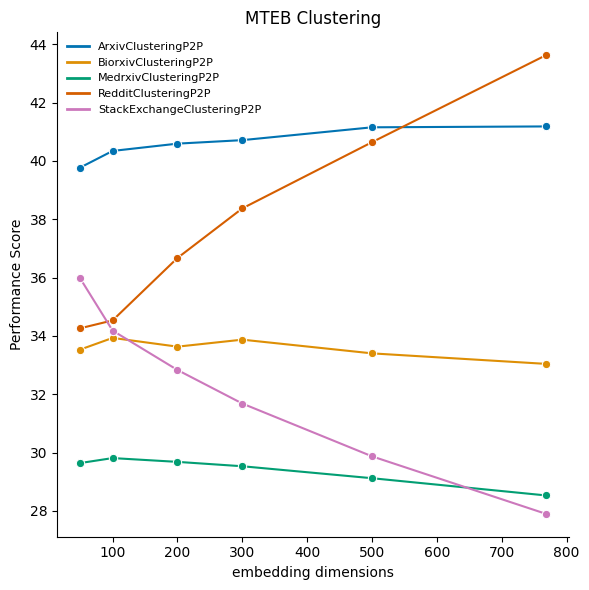

In [16]:
# plot only for clustering
task_type = "Clustering"
fig, ax = plt.subplots(1, figsize=(6,6), layout="constrained")

df_task = df_melted[df_melted["task_types"] == task_type]
# make color dict per task type
task_names = df_task["task_name"].unique()
colors_dict = dict(zip(task_names, sns.color_palette("colorblind", len(task_names))))
# draw lineplots for each reduction type (here: only svd)
df_subset = df_task[df_melted["reduction type"] == "svd"]
    
# one line for each task name
for task in df_subset["task_name"].unique():
    task_subset = df_subset[df_subset["task_name"] == task]
    task_subset_sorted = task_subset.sort_values("embedding dimensions")
    sns.lineplot(data=task_subset_sorted, x="embedding dimensions", y="score",
                hue="task_name", palette=colors_dict, alpha=opacity_dict["svd"],
                ax=ax, markers=True, style="task_types", legend=False)

# task name legends
svd_colors = [Line2D([0], [0], color=color, lw=2, label=task_name)
             for task_name, color in colors_dict.items()]
ax.legend(handles=svd_colors, frameon=False, prop={'size': 8}, loc="upper left")
    
# design stuff
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Performance Score")
ax.set_title(f"MTEB Clustering")

plt.tight_layout()

plt.savefig("../img/MTEB_clustering.png", bbox_inches='tight')

/var/folders/bd/rr8tbyms7wn9f6zw11rfsq_40000gn/T/ipykernel_52019/2785256960.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_subset = df_task[df_melted["reduction type"] == red]
/var/folders/bd/rr8tbyms7wn9f6zw11rfsq_40000gn/T/ipykernel_52019/2785256960.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_subset = df_task[df_melted["reduction type"] == red]
/var/folders/bd/rr8tbyms7wn9f6zw11rfsq_40000gn/T/ipykernel_52019/2785256960.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_subset = df_task[df_melted["reduction type"] == red]
/var/folders/bd/rr8tbyms7wn9f6zw11rfsq_40000gn/T/ipykernel_52019/2785256960.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_subset = df_task[df_melted["reduction type"] == red]
/var/folders/bd/rr8tbyms7wn9f6zw11rfsq_40000gn/T/ipykernel_52019/2785256960.py:19: UserWarning: Boolean Series key will be reindexed

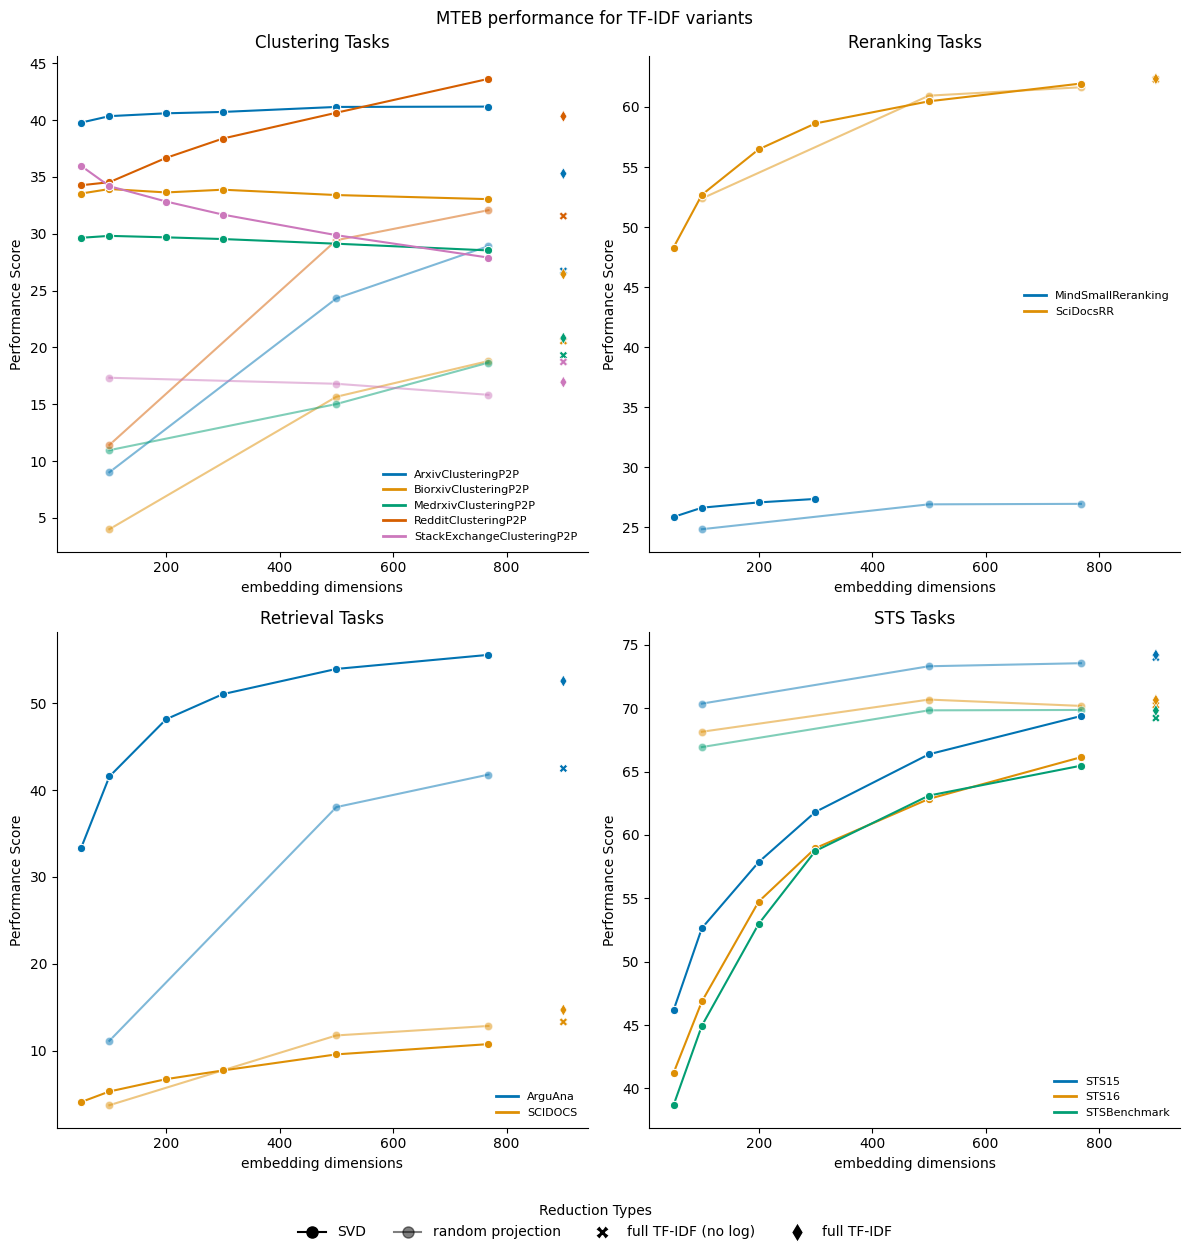

In [21]:
task_types = list(df_melted["task_types"].unique())

fig, axs = plt.subplots(2,2, figsize=(12,12), layout="constrained")

# iterate through axes
for i in range(2):
    for j in range(2):
        ax = axs[i,j]
        
        task_type = task_types[i*2+j]
        
        # each subplot shows 1 task type
        df_task = df_melted[df_melted["task_types"] == task_type]
        # make color dict per task type
        task_names = df_task["task_name"].unique()
        colors_dict = dict(zip(task_names, sns.color_palette("colorblind", len(task_names))))
        # draw lineplots for each reduction type
        for red in reduction_types:
            df_subset = df_task[df_melted["reduction type"] == red]
    
            # one line for each task name
            for task in df_subset["task_name"].unique():
                task_subset = df_subset[df_subset["task_name"] == task]
                task_subset_sorted = task_subset.sort_values("embedding dimensions")
                sns.lineplot(data=task_subset_sorted, x="embedding dimensions", y="score",
                            hue="task_name", palette=colors_dict, alpha=opacity_dict[red],
                            ax=ax, markers=True, style="task_types", legend=False)
        
        # draw single markers for full tf-idf models 
        full_models = ["full tfidf (no log)", "full tfidf"]
        df_full = df_task[df_task["version"].isin(full_models)]     
        sns.scatterplot(data=df_full, x='embedding dimensions', y='score', hue="task_name", palette=colors_dict, 
                        style="version", markers=dict(zip(full_models, ["X", "d"])), ax=ax, alpha=1.0, legend=False)

        # task name legends
        # Add legend for task names (only for svd, full opacity)
        svd_colors = [
            Line2D([0], [0], color=color, lw=2, label=task_name)
            for task_name, color in colors_dict.items()
        ]
        if task_type == "Reranking":
            # need to manually set location for Retrieval panel
            ax.legend(handles=svd_colors, frameon=False, prop={'size': 8}, loc="center right")
        else:
            ax.legend(handles=svd_colors, frameon=False, prop={'size': 8}, loc="lower right")
    
        # design stuff
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_ylabel("Performance Score")
        
    
        ax.set_title(f"{task_type} Tasks")
    
# Create a legend below the panels for reduction types and model versions
legend_elements = [
    Line2D([0], [0], marker="o", color="black", markerfacecolor="black", markersize=8, label="SVD", alpha=1.0),
    Line2D([0], [0], marker="o", color="black", markerfacecolor="black", markersize=8, label="random projection", alpha=0.5),
    Line2D([0], [0], marker="X", color="w", markerfacecolor="black", markersize=10, label="full TF-IDF (no log)"),
    Line2D([0], [0], marker="d", color="w", markerfacecolor="black", markersize=10, label="full TF-IDF"),
]
fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=4,
    title="Reduction Types",
    bbox_to_anchor=(0.5, -0.005),
    frameon=False,
)



plt.suptitle("MTEB performance for TF-IDF variants")
plt.tight_layout()

plt.savefig("../img/MTEB_tfidf.png", bbox_inches='tight')

### Figure 2 / Table 2: compare TF-IDF with other models
other models considered:
- glove 
- sentenceBERT (mpnet)
- MPcrops
- simcse
- scincl

tfidf versions:
- tfidf_log
- svd_log
- svd768_log



In [13]:
# read model results for non-tfidf models
data = {}
main_dir = "../MTEB/results"

# Traverse folders and subfolders
for (root, dirs, files) in os.walk(main_dir):
    # Identify model version from the folder structure
    model_version = root.removeprefix("../MTEB/results/")
        
    for file in files:
        # Skip unwanted files
        if file in {"model_meta.json"} or not file.endswith('.json'):
            continue
            
        file_path = os.path.join(root, file)
        try:
            # Read JSON and extract necessary fields
            with open(file_path, 'r') as f:
                json_data = json.load(f)
                task_name = json_data.get("task_name")
                main_score = json_data.get("scores", {}).get("test", {})[0]["main_score"]
                main_score = round(main_score*100, 2)
                    
                if task_name and main_score is not None:
                    if task_name not in data:
                        data[task_name] = {}
                    data[task_name][model_version] = main_score
        except (json.JSONDecodeError, KeyError):
            print(f"Error parsing file: {file_path}")

Error parsing file: ../MTEB/results/average_word_embeddings_komninos/21eec43590414cb8e3a6f654857abed0483ae36e/BibleNLPBitextMining.json


In [14]:
df_other = pd.DataFrame.from_dict(data, orient='index')
df_other.index.name = "task_name"
df_other["task_types"] = [mteb.get_task(task).metadata.type for task in df_other.index]

In [15]:
task_selection = ["ArguAna", "ArxivClusteringP2P", "BiorxivClusteringP2P", "MedrxivClusteringP2P", "MindSmallReranking",
                 "RedditClusteringP2P", "SCIDOCS", "SciDocsRR", "StackExchangeClusteringP2P", "STS15", "STS16",
                 "STSBenchmark"]

df_other = df_other.loc[task_selection].sort_values("task_types")
df_other = df_other.drop(["sentence-transformers__average_word_embeddings_glove.6B.300d/no_revision_available",
                          "average_word_embeddings_komninos/21eec43590414cb8e3a6f654857abed0483ae36e"], axis=1)
df_other

,sentence-transformers__average_word_embeddings_glove.6B.300d/b23c24e861d95672ff40c1c64442c45e48235960,princeton-nlp__unsup-simcse-bert-base-uncased/218baf6bc48c463a53f5b4e1c568299537fab124,sentence-transformers__all-mpnet-base-v2/f1b1b820e405bb8644f5e8d9a3b98f9c9e0a3c58,malteos__scincl/ebc5348d184ba2fc9beee69b4e394263fce57b2e,task_types
task_name,,,,,
ArxivClusteringP2P,32.74,35.42,48.12,46.15,Clustering
BiorxivClusteringP2P,29.32,30.10,39.32,38.76,Clustering
MedrxivClusteringP2P,26.12,28.03,35.59,35.95,Clustering
RedditClusteringP2P,35.89,44.70,56.60,37.52,Clustering
StackExchangeClusteringP2P,28.45,28.82,34.22,33.70,Clustering
MindSmallReranking,27.01,29.25,30.97,28.71,Reranking
SciDocsRR,62.56,69.52,88.65,85.85,Reranking
ArguAna,36.30,41.43,46.52,35.82,Retrieval
SCIDOCS,8.04,7.90,23.77,19.51,Retrieval


In [16]:
df_other.rename(columns={'sentence-transformers__average_word_embeddings_glove.6B.300d/b23c24e861d95672ff40c1c64442c45e48235960': 'glove', 
                         'princeton-nlp__unsup-simcse-bert-base-uncased/218baf6bc48c463a53f5b4e1c568299537fab124': 'SimCSE',
                         'sentence-transformers__all-mpnet-base-v2/f1b1b820e405bb8644f5e8d9a3b98f9c9e0a3c58': 'SBERT',
                         'malteos__scincl/ebc5348d184ba2fc9beee69b4e394263fce57b2e': 'SciNCL'},
                inplace=True)
# add Rita's Crops results
df_other["MPNet_Crops"] = [38.3, 32.4,30.8,55.9, 31.3, 30.2, 73.6, 50.6, 13.0, 72.5, 76.0, 71.7]
# add Rita's MPNet results 
df_other["MPNet"] = [27.8, 23.2, 22.5, 37.4, 26.3, 27.5, 56.1, 22.2, 1.4, 53.5, 50.6, 52.0]
# add tfidf models
df_other = df_other.merge(df_mteb[["full tfidf", "svd_log", "svd768_log"]], on="task_name")

model_order = ["full tfidf", "svd_log", "svd768_log", "glove", "MPNet", "SBERT", "SimCSE", "SciNCL", "MPNet_Crops", "task_types"]
df_other.index = df_other.index.str.strip()
df_other = df_other.reindex(columns=model_order)
df_other = df_other.rename(columns={"full tfidf": "TF-IDF (full)", "svd_log": "TF-IDF SVD (100)", "svd768_log": "TF-IDF SVD (768)"})
df_other

,TF-IDF (full),TF-IDF SVD (100),TF-IDF SVD (768),glove,MPNet,SBERT,SimCSE,SciNCL,MPNet_Crops,task_types
task_name,,,,,,,,,,
ArxivClusteringP2P,35.28,40.34,41.18,32.74,27.8,48.12,35.42,46.15,38.3,Clustering
BiorxivClusteringP2P,26.44,33.93,33.04,29.32,23.2,39.32,30.10,38.76,32.4,Clustering
MedrxivClusteringP2P,20.82,29.81,28.53,26.12,22.5,35.59,28.03,35.95,30.8,Clustering
RedditClusteringP2P,40.32,34.53,43.62,35.89,37.4,56.60,44.70,37.52,55.9,Clustering
StackExchangeClusteringP2P,16.94,34.18,27.90,28.45,26.3,34.22,28.82,33.70,31.3,Clustering
MindSmallReranking,NaN,26.64,NaN,27.01,27.5,30.97,29.25,28.71,30.2,Reranking
SciDocsRR,62.34,52.69,61.95,62.56,56.1,88.65,69.52,85.85,73.6,Reranking
ArguAna,52.54,41.56,55.56,36.30,22.2,46.52,41.43,35.82,50.6,Retrieval
SCIDOCS,14.69,5.31,10.76,8.04,1.4,23.77,7.90,19.51,13.0,Retrieval


In [17]:
df_other.to_latex(na_rep="-", float_format="%.2f")

'\\begin{tabular}{lrrrrrrrrrl}\n\\toprule\n & TF-IDF (full) & TF-IDF SVD (100) & TF-IDF SVD (768) & glove & MPNet & SBERT & SimCSE & SciNCL & MPNet_Crops & task_types \\\\\ntask_name &  &  &  &  &  &  &  &  &  &  \\\\\n\\midrule\nArxivClusteringP2P & 35.28 & 40.34 & 41.18 & 32.74 & 27.80 & 48.12 & 35.42 & 46.15 & 38.30 & Clustering \\\\\nBiorxivClusteringP2P & 26.44 & 33.93 & 33.04 & 29.32 & 23.20 & 39.32 & 30.10 & 38.76 & 32.40 & Clustering \\\\\nMedrxivClusteringP2P & 20.82 & 29.81 & 28.53 & 26.12 & 22.50 & 35.59 & 28.03 & 35.95 & 30.80 & Clustering \\\\\nRedditClusteringP2P & 40.32 & 34.53 & 43.62 & 35.89 & 37.40 & 56.60 & 44.70 & 37.52 & 55.90 & Clustering \\\\\nStackExchangeClusteringP2P & 16.94 & 34.18 & 27.90 & 28.45 & 26.30 & 34.22 & 28.82 & 33.70 & 31.30 & Clustering \\\\\nMindSmallReranking & - & 26.64 & - & 27.01 & 27.50 & 30.97 & 29.25 & 28.71 & 30.20 & Reranking \\\\\nSciDocsRR & 62.34 & 52.69 & 61.95 & 62.56 & 56.10 & 88.65 & 69.52 & 85.85 & 73.60 & Reranking \\\\\nArguAn

In [37]:
# Reshape DataFrame for plotting
df_melted = df_other.reset_index().melt(id_vars=['task_name', 'task_types'], var_name='model', value_name='score')

# Assign unique x positions for tasks
task_order = {"ArxivClusteringP2P": 1,
              "BiorxivClusteringP2P": 2,
              "MedrxivClusteringP2P": 3,
              "RedditClusteringP2P": 4,
              "StackExchangeClusteringP2P": 5,
              "MindSmallReranking": 6,
              "SciDocsRR": 7,
              "ArguAna": 8,
              "SCIDOCS": 9,
              "STS15": 10,
              "STS16": 11,
              "STSBenchmark": 12
              }

df_melted["x_pos"] = [task_order[t] for t in df_melted["task_name"]]

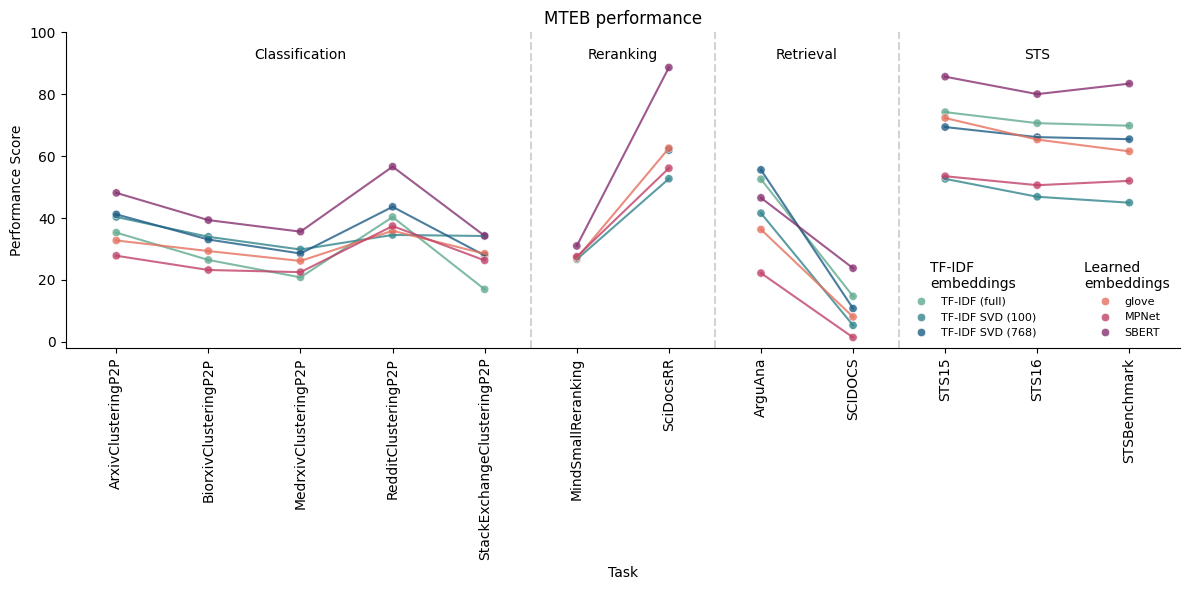

In [ ]:
# color matching for models
models = df_melted["model"].unique()
colors_dict = dict(zip(models, sns.color_palette("crest", 3)+sns.color_palette("flare", 5)))

# single plot without ngram opacity
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(data=df_melted, x='x_pos', y='score', hue="model", palette=colors_dict, alpha=0.8)

# Draw lines connecting tasks within the same category for each model
for model in df_melted['model'].unique():
    subset = df_melted[df_melted['model'] == model]
    for category in subset['task_types'].unique():
        category_subset = subset[subset['task_types'] == category]
        category_subset_sorted = category_subset.sort_values("x_pos")
        sns.lineplot(data=category_subset_sorted, x='x_pos', y='score', hue='model', palette=colors_dict, 
                     legend=False, alpha=0.8)

# add task type text
tasks = ["Clustering", "Reranking", "Retrieval", "STS"]
placement = [3, 6.5, 8.5, 11]
for task, place in zip(tasks, placement):
    plt.text(place, 95, task, horizontalalignment = "center", verticalalignment = "top")
# task type boundaries
boundaries = [0.5, 5.5, 7.5, 9.5, 12.5]
for i in range(1, len(boundaries)-1):
    plt.axvline(boundaries[i], linestyle = "dashed", color = "lightgrey")
    


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend customization
handles, labels = ax.get_legend_handles_labels()

# First column: TF-IDF embeddings (first 3 models)
handles_tfidf = handles[:3]
labels_tfidf = labels[:3]

# Second column: Learned embeddings (remaining 5 models)
handles_learned = handles[3:]
labels_learned = labels[3:]

# Create the two-column legend
legend1 = ax.legend(
    handles_tfidf, labels_tfidf, title="TF-IDF \nembeddings", loc="lower right", 
    bbox_to_anchor=(0.88, 0), frameon=False, ncol=1, prop={'size': 8}
)
legend2 = ax.legend(
    handles_learned, labels_learned, title="Learned \nembeddings", loc="lower right", 
    bbox_to_anchor=(1.0, 0), frameon=False, ncol=1, prop={'size': 8}
)

# Add both legends to the plot
ax.add_artist(legend1)
#ax.add_artist(legend2)

#plt.legend(frameon=False, ncol=2, loc="lower right", prop={'size': 8})
plt.title('MTEB performance')
plt.xlabel('Task')
plt.ylabel('Performance Score')
plt.ylim(-2,100)
plt.xticks(range(1,13), labels=list(task_order.keys()), rotation=90)
plt.tight_layout()
plt.savefig("../img/MTEB_model_comparison_all.png")


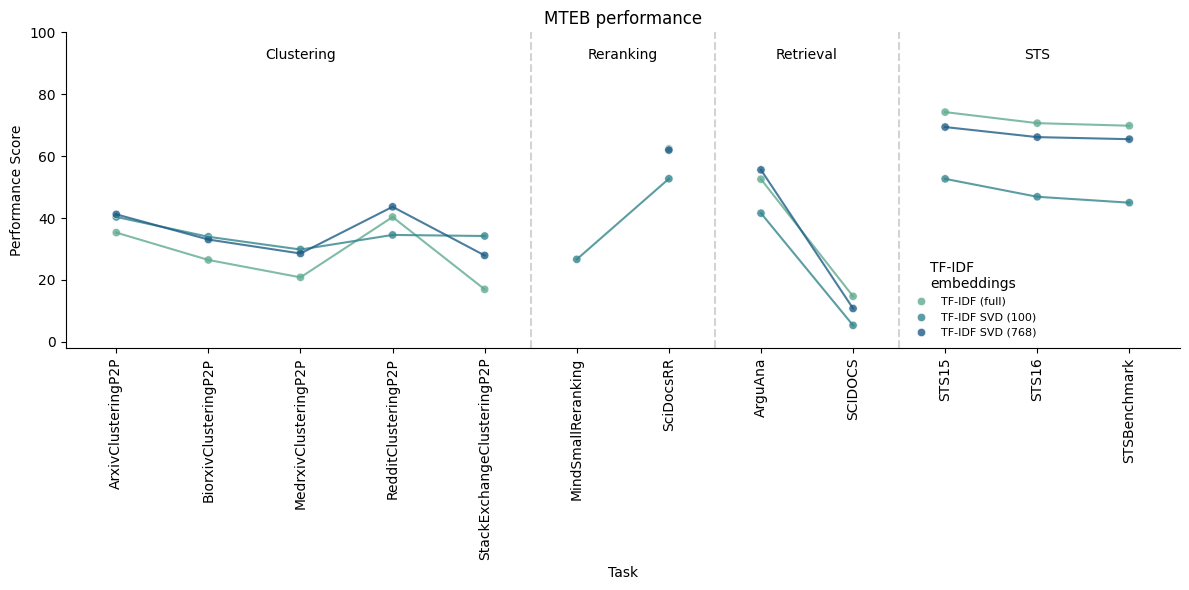

In [43]:
## plot comparing only TF-IDF models

# color matching for models
models = df_melted["model"].unique()
colors_dict = dict(zip(models, sns.color_palette("crest", 3)+sns.color_palette("flare", 5)))

df_tfidf = df_melted[df_melted['model'].isin(["TF-IDF (full)", "TF-IDF SVD (100)", "TF-IDF SVD (768)"])]

# single plot without ngram opacity
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(data=df_tfidf, x='x_pos', y='score', hue="model", palette=colors_dict, alpha=0.8)

# Draw lines connecting tasks within the same category for each model
for model in df_tfidf['model'].unique():
    subset = df_tfidf[df_tfidf['model'] == model]
    for category in subset['task_types'].unique():
        category_subset = subset[subset['task_types'] == category]
        category_subset_sorted = category_subset.sort_values("x_pos")
        sns.lineplot(data=category_subset_sorted, x='x_pos', y='score', hue='model', palette=colors_dict, 
                     legend=False, alpha=0.8)

# add task type text
tasks = ["Clustering", "Reranking", "Retrieval", "STS"]
placement = [3, 6.5, 8.5, 11]
for task, place in zip(tasks, placement):
    plt.text(place, 95, task, horizontalalignment = "center", verticalalignment = "top")
# task type boundaries
boundaries = [0.5, 5.5, 7.5, 9.5, 12.5]
for i in range(1, len(boundaries)-1):
    plt.axvline(boundaries[i], linestyle = "dashed", color = "lightgrey")
    


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend customization
handles, labels = ax.get_legend_handles_labels()

# First column: TF-IDF embeddings (first 3 models)
handles_tfidf = handles[:3]
labels_tfidf = labels[:3]

# Second column: Learned embeddings (remaining 5 models)
handles_learned = handles[3:]
labels_learned = labels[3:]

# Create the two-column legend
legend1 = ax.legend(
    handles_tfidf, labels_tfidf, title="TF-IDF \nembeddings", loc="lower right", 
    bbox_to_anchor=(0.88, 0), frameon=False, ncol=1, prop={'size': 8}
)

# Add both legends to the plot
#ax.add_artist(legend1)

#plt.legend(frameon=False, ncol=2, loc="lower right", prop={'size': 8})
plt.title('MTEB performance')
plt.xlabel('Task')
plt.ylabel('Performance Score')
plt.ylim(-2,100)
plt.xticks(range(1,13), labels=list(task_order.keys()), rotation=90)
plt.tight_layout()
plt.savefig("../img/MTEB_model_comparison_tfidf.png")


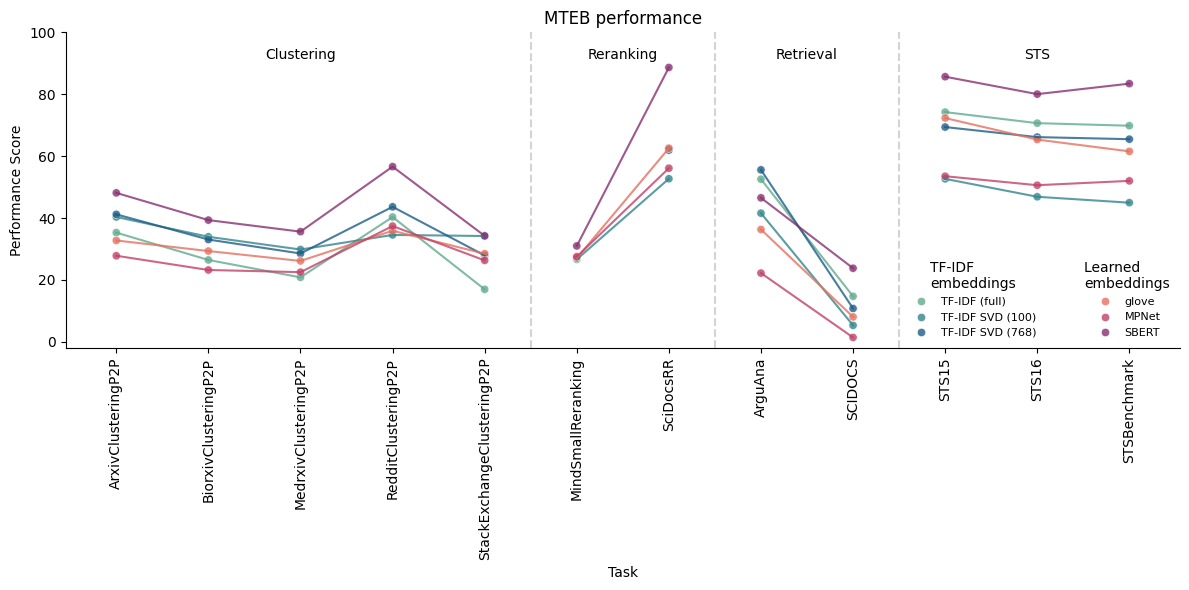

In [44]:
# color matching for models
models = df_melted["model"].unique()
colors_dict = dict(zip(models, sns.color_palette("crest", 3)+sns.color_palette("flare", 3)))

# single plot without ngram opacity
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(data=df_melted, x='x_pos', y='score', hue="model", palette=colors_dict, alpha=0.8)

# Draw lines connecting tasks within the same category for each model
for model in df_melted['model'].unique():
    subset = df_melted[df_melted['model'] == model]
    for category in subset['task_types'].unique():
        category_subset = subset[subset['task_types'] == category]
        category_subset_sorted = category_subset.sort_values("x_pos")
        sns.lineplot(data=category_subset_sorted, x='x_pos', y='score', hue='model', palette=colors_dict, 
                     legend=False, alpha=0.8)

# add task type text
tasks = ["Clustering", "Reranking", "Retrieval", "STS"]
placement = [3, 6.5, 8.5, 11]
for task, place in zip(tasks, placement):
    plt.text(place, 95, task, horizontalalignment = "center", verticalalignment = "top")
# task type boundaries
boundaries = [0.5, 5.5, 7.5, 9.5, 12.5]
for i in range(1, len(boundaries)-1):
    plt.axvline(boundaries[i], linestyle = "dashed", color = "lightgrey")
    


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend customization
handles, labels = ax.get_legend_handles_labels()

# First column: TF-IDF embeddings (first 3 models)
handles_tfidf = handles[:3]
labels_tfidf = labels[:3]

# Second column: Learned embeddings (remaining 5 models)
handles_learned = handles[3:]
labels_learned = labels[3:]

# Create the two-column legend
legend1 = ax.legend(
    handles_tfidf, labels_tfidf, title="TF-IDF \nembeddings", loc="lower right", 
    bbox_to_anchor=(0.88, 0), frameon=False, ncol=1, prop={'size': 8}
)
legend2 = ax.legend(
    handles_learned, labels_learned, title="Learned \nembeddings", loc="lower right", 
    bbox_to_anchor=(1.0, 0), frameon=False, ncol=1, prop={'size': 8}
)

# Add both legends to the plot
ax.add_artist(legend1)
#ax.add_artist(legend2)

#plt.legend(frameon=False, ncol=2, loc="lower right", prop={'size': 8})
plt.title('MTEB performance')
plt.xlabel('Task')
plt.ylabel('Performance Score')
plt.ylim(-2,100)
plt.xticks(range(1,13), labels=list(task_order.keys()), rotation=90)
plt.tight_layout()
plt.savefig("../img/MTEB_model_comparison.png")
